# Research Agent API - Synchronous Client

A robust Python client for the [Bigdata.com Research Agent API](https://docs.bigdata.com/how-to-guides/agents) that consumes the Server-Sent Events stream and hands back one finished result: the answer, correctly attributed citations, and any charts the agent produced.

## Features

| Feature | Description |
|---------|-------------|
| **Synchronous interface** | One blocking call - no async/await |
| **Complete message coverage** | Every public SSE message type is handled; unknown types are ignored so new API versions do not break the client |
| **Accurate citations** | Document citations and whole-tool attributions are handled separately, so a reference never renders as a blank `N/A` entry |
| **Typed errors** | HTTP status codes and in-stream `ERROR` events map to specific exception classes |
| **Automatic retries** | Exponential backoff with jitter for `429`, `5xx`, and transient network failures |
| **Charts** | `CHART` events are collected as Vega-Lite specs anchored to answer offsets |
| **Conversation continuity** | `chat_id` follow-ups and `checkpoint_id` branching |

## Reference documentation

- [Concepts overview](https://docs.bigdata.com/how-to-guides/agents/concepts/overview)
- [Streaming responses](https://docs.bigdata.com/how-to-guides/agents/concepts/streaming-responses)
- [Grounding and citations](https://docs.bigdata.com/how-to-guides/agents/concepts/grounding-and-citations)
- [Code execution and charts](https://docs.bigdata.com/how-to-guides/agents/concepts/code-execution-and-charts)
- [Error handling](https://docs.bigdata.com/how-to-guides/agents/concepts/error-handling)

---
## 1. Setup

The client needs `requests` and a `BIGDATA_API_KEY`. Everything else is standard library.

In [1]:
import json
import logging
import os

from IPython.display import Markdown, display

from research_client import ResearchClient, format_source_date, setup_logging

os.makedirs("output", exist_ok=True)

# Logging is flushed on every record, so the log file survives a hard failure
# mid-stream. Set console=False to keep the notebook output quiet.
setup_logging(
    log_file="output/research_client.log",
    level=logging.INFO,
    console=False,
    file_mode="w",
)

print("Ready.")

Ready.


---
## 2. Configure the client

Retry, timeout, and tool settings are all set once on the client. Per-request overrides are available on `research()`.

| Parameter | Default | Description |
|-----------|---------|-------------|
| `timeout` | `300` | Connection timeout in seconds |
| `stream_timeout` | `60.0` | Max seconds to wait between SSE chunks before treating the connection as stalled |
| `max_retries` | `3` | Retry attempts for transient failures |
| `retry_delay` | `1.0` | Initial backoff delay |
| `retry_backoff` | `2.0` | Exponential backoff multiplier |
| `retry_max_delay` | `60.0` | Upper bound on the backoff delay |
| `persistence_mode` | `"enabled"` | Saves conversation history so `chat_id` follow-ups work. The API itself defaults to `"disabled"` |
| `code_execution` | `None` | Whether the agent may run sandboxed Python. `None` keeps the server default (on) |
| `chart_generation` | `None` | Whether the agent may emit `CHART` events. `None` keeps the server default (off) |

Backoff uses **full jitter** (`delay + random(0, delay)`), which is the pattern the
[error handling guide](https://docs.bigdata.com/how-to-guides/agents/concepts/error-handling#retry-and-backoff) recommends for `429` and `5xx`.

In [2]:
client = ResearchClient(
    # Timeouts
    timeout=300,
    stream_timeout=90.0,
    # Retries
    max_retries=3,
    retry_delay=2.0,
    retry_backoff=2.0,
    retry_max_delay=60.0,
    # Conversation history, required for follow_up()
    persistence_mode="enabled",
    # Let the agent run Python and draw charts
    code_execution=True,
    chart_generation=True,
)

print("Client configured.")

Client configured.


### Demonstrate retries

Transient failures such as a dropped connection, a `429`, or a `5xx` are retried automatically with exponential backoff and full jitter. Permanent client errors (`400`, `401`, `403`, `404`) are raised immediately.

A live outage is rare while you are reading this notebook, so the cell below **injects one retryable failure** on the first `requests.post`, then lets the real call through. Watch for the `Retryable error` / `Retry 1/3` log lines.

In [3]:
import logging
from unittest.mock import patch

from requests.exceptions import ConnectionError as RequestsConnectionError

from research_client import logger as research_logger

# Short delays so the demo finishes quickly; the main `client` above keeps the
# production-style retry profile for the rest of the notebook.
retry_demo_client = ResearchClient(
    timeout=300,
    stream_timeout=90.0,
    max_retries=3,
    retry_delay=0.5,
    retry_backoff=2.0,
    retry_max_delay=5.0,
    persistence_mode="enabled",
)

# Surface retry warnings in the notebook output for this cell only.
console = logging.StreamHandler()
console.setLevel(logging.WARNING)
console.setFormatter(logging.Formatter("%(levelname)s - %(message)s"))
research_logger.addHandler(console)

call_count = {"n": 0}
real_post = __import__("requests").post


def flaky_post(*args, **kwargs):
    """Fail once with a retryable network error, then behave normally."""
    call_count["n"] += 1
    if call_count["n"] == 1:
        raise RequestsConnectionError("simulated dropped connection (demo)")
    return real_post(*args, **kwargs)


print("Forcing a ConnectionError on attempt 1, then succeeding...\n")

with patch("requests.post", side_effect=flaky_post):
    retry_demo = retry_demo_client.research(
        message="What is the current level of the Nasdaq 100?",
        research_effort="lite",
    )

research_logger.removeHandler(console)

print(f"\nHTTP attempts: {call_count['n']}  (1 failure + 1 success)")
print(f"Answer length: {len(retry_demo.answer):,} characters")
print(f"Processing time: {retry_demo.processing_time_ms}ms")
print("Retry path exercised successfully.")

WARNING - Retryable error on attempt 1/4: ConnectionError: simulated dropped connection (demo)


WARNING - Retry 1/3 in 0.6s


Forcing a ConnectionError on attempt 1, then succeeding...




HTTP attempts: 2  (1 failure + 1 success)
Answer length: 83 characters
Processing time: 13009ms
Retry path exercised successfully.


---
## 3. Run a research query

The agent streams typed events while it works. Passing an `on_event` callback lets you show progress without dealing with the stream yourself.

A `research_effort` of `"lite"` returns in roughly 10-20 seconds; `"standard"` runs multi-step research and takes 20-60 seconds.

In [4]:
QUERY = "How is Nasdaq 100 Performing?"


def make_progress_printer():
    """
    Build an `on_event` callback that prints a compact progress line per event.

    PLANNING resends the whole plan every time it changes, so already-reported
    steps are suppressed rather than reprinted.
    """
    reported: set[str] = set()

    def show_progress(msg_type: str, msg: dict) -> None:
        if msg_type == "PLANNING":
            for step in msg.get("plan", {}).get("steps", []):
                line = f"  [{step.get('status', '').lower()}] {step.get('description')}"
                if step.get("status") in ("IN_PROGRESS", "COMPLETED") and line not in reported:
                    reported.add(line)
                    print(line)
        elif msg_type == "ACTION":
            print(f"  action: {msg.get('tool_name')}")
        elif msg_type == "CHART":
            print(f"  chart: {msg.get('title')} ({msg.get('chart_type')})")
        elif msg_type == "TOOL_ERROR":
            print(f"  tool error: {msg.get('tool_name')} - {msg.get('error')}")
        elif msg_type == "LLM_RETRY":
            print(f"  agent retrying: {msg.get('message')}")

    return show_progress


print(f"Researching: {QUERY}\n")

result = client.research(
    message=QUERY,
    research_effort="standard",
    on_event=make_progress_printer(),
)

print(f"\nDone in {result.processing_time_ms / 1000:.1f}s")
print(f"  answer:         {len(result.answer):,} characters")
print(f"  documents:      {len(result.citations)}")
print(f"  grounded spans: {len(result.grounding_refs)}")
print(f"  charts:         {len(result.charts)}")
print(f"  tool errors:    {result.tool_errors or 'none'}")
print(f"  chat_id:        {result.chat_id}")
print(f"  checkpoint_id:  {result.checkpoint_id}")

Researching: How is Nasdaq 100 Performing?



  [in_progress] Gather global market context using get_market_tearsheet.
  [in_progress] Research Nasdaq 100 (NDX) performance data (YTD and last 30 days) and recent news.
  action: search
  action: get_market_tearsheet


  [completed] Gather global market context using get_market_tearsheet.
  [completed] Research Nasdaq 100 (NDX) performance data (YTD and last 30 days) and recent news.
  [completed] Identify key drivers (macroeconomic, sector/company-specific) of the Nasdaq 100's recent performance.
  [completed] Assess current analyst sentiment and outlook for the Nasdaq 100.



Done in 41.9s
  answer:         2,962 characters
  documents:      20
  grounded spans: 7
  charts:         0
  tool errors:    none
  chat_id:        1785346556-69386022-25fb-417e-9020-c92b4426a931
  checkpoint_id:  1f18b740-af85-610a-800e-f0cafd1406d3


---
## 4. Answer with inline citations

`GROUNDING` events attribute spans of the answer to their sources using `start`/`end` character offsets into the **cumulative** answer text. The client buffers every `ANSWER` chunk verbatim and only resolves those offsets once the stream is complete, which is the rule the [grounding guide](https://docs.bigdata.com/how-to-guides/agents/concepts/grounding-and-citations#the-buffering-rule) sets out.

Two kinds of reference come back, and they need different rendering:

| `source` | Meaning | Rendered as |
|---|---|---|
| Populated | A document returned by the **search** tool | Headline, publisher, date, and URL |
| Absent | Every **other** tool (market tearsheet, earnings calendar, code execution) grounds the span at the whole-tool level via `audit_id` | The tool's audit title, e.g. *Market Tearsheet* |

Treating the second kind as a document is what produced blank `N/A` citations. The client now resolves it against the matching `AUDIT` trace instead.

In [5]:
def print_citation(numbered_citations):
    for citation in numbered_citations:
        number = citation["number"]

        if citation.get("type") == "TOOL":
            # Whole-tool attribution: no document, so label it with the audit title.
            title = citation.get("title") or citation["tool_name"]
            parts = [
                f"**[{number}]** {title}",
                f"Bigdata.com tool &nbsp;`{citation['tool_name']}`",
            ]
            display(Markdown("<br>".join(parts) + "\n\n---"))
            continue

        source = citation.get("source") or {}
        parts = [f"**[{number}]** {citation.get('headline', '')}".rstrip()]

        meta = []
        if source.get("name"):
            meta.append(source["name"])
        if citation.get("timestamp"):
            meta.append(format_source_date(citation["timestamp"]))
        if meta:
            parts.append(" &nbsp;|&nbsp; ".join(meta))
        if citation.get("url"):
            parts.append(f"[{citation['url'][:70]}]({citation['url']})")

        excerpts = [c.get("text", "") for c in citation.get("chunks", [])[:2]]
        body = "<br>".join(parts)
        for excerpt in excerpts:
            if excerpt:
                trimmed = excerpt.replace("\n", " ")[:300]
                body += f"\n\n> *{trimmed}...*"

        display(Markdown(body + "\n\n---"))

In [6]:
answer_with_citations = result.get_answer_with_citations()
numbered_citations = result.get_numbered_citations()

display(Markdown("## Answer\n\n" + answer_with_citations))

display(Markdown(f"---\n## References ({len(numbered_citations)})\n"))
print_citation(numbered_citations)

## Answer

### Executive Summary
The Nasdaq 100 is currently undergoing a period of correction, having pulled back roughly 8% from recent peaks amid growing investor skepticism regarding the long-term sustainability of the artificial intelligence infrastructure spending boom [1]. While the index maintains a positive year-to-date return, its recent 30-day performance reflects a challenging environment characterized by increased volatility and shifting sentiment within the technology and semiconductor sectors. The market is currently attempting to balance long-term optimism surrounding AI-driven productivity against near-term macroeconomic headwinds and valuation concerns.

### Key Performance Metrics

| Metric | Value |
|---|---|
| Current Index Level | 27,505.12 |
| YTD Return | +8.93% |
| 1-Month Change | -7.62% |
| 1-Day Change | -0.93% |

*Data as of July 29, 2026. Source: FMP, Market Data.*

### Primary Drivers
The following factors are currently influencing the direction of the Nasdaq 100:

*   **AI Infrastructure Sustainability:** Concerns regarding the longevity and profitability of heavy capital expenditure in the AI sector have become a primary weight on the index. Analysts are increasingly focused on whether the massive investments in AI hardware will translate into sustained corporate earnings growth [1].
*   **Index Reconstitution and Passive Flows:** The recent addition of high-profile companies—including SpaceX (July 2026), CoreWeave (June 2026), and Nebius Group (June 2026)—to the Nasdaq-100 has shifted index composition [2, 3, 4]. These additions often trigger rebalancing by passive funds, affecting liquidity and volatility for these specific constituents and the broader index.
*   **Semiconductor Volatility:** Performance remains tethered to the semiconductor and storage sectors, where supply-demand imbalances and capital expenditure cycles are creating uneven results. While some companies continue to see "triple-digit" growth due to AI demand, others have faced scrutiny over margin guidance and inventory normalization [5].
*   **Macroeconomic Sensitivity:** As with the broader equity market, the index remains highly sensitive to interest rate expectations and inflationary trends, which continue to pressure growth-oriented valuations.

### Market Sentiment/Outlook
Market sentiment toward the Nasdaq 100 is currently cautious, with a focus on risk management. The index’s 8% pullback from recent highs has led to increased discussion of potential "technical bear market" territory, a threshold that, if breached, could lead to significant momentum-driven selling as seen in previous cycles [1]. Investors are prioritizing earnings quality and concrete guidance on AI-related ROI. Until there is more definitive data confirming that the AI infrastructure spending cycle is stabilizing rather than peaking, the index is likely to remain in a consolidative or corrective phase as the market re-evaluates high-valuation technology multiples.

---
## References (5)


**[1]** Prediction: Tesla Stock Will Plunge to $100 If the Nasdaq Enters a Bear Market<br>The Globe And Mail &nbsp;|&nbsp; Jul 27, 2026<br>[https://www.theglobeandmail.com/investing/markets/markets-news/Motley%](https://www.theglobeandmail.com/investing/markets/markets-news/Motley%20Fool/3485745/prediction-tesla-stock-will-plunge-to-100-if-the-nasdaq-enters-a-bear-market/)

> *Key Points The Nasdaq-100 technology index is down 8% from its recent peak, due to concerns about the sustainability of the artificial intelligence infrastructure spending boom. Last time the Nasdaq-100 plunged by 20% and entered a bear market, Tesla stock plummeted by 75% to around $100. History co...*

---

**[2]** SpaceX is joining the Nasdaq 100. Here's what to know SpaceX is set to officially join the Nasdaq 100 index on Tuesday, giving investors new exposure to the stock while triggering billions of dollars in automatic purchases by index funds.<br>CNN &nbsp;|&nbsp; Jul 07, 2026<br>[https://edition.cnn.com/2026/07/07/economy/spacex-nasdaq-100-stocks](https://edition.cnn.com/2026/07/07/economy/spacex-nasdaq-100-stocks)

> *New York - SpaceX is set to officially join the Nasdaq 100 index on Tuesday, giving investors new exposure to the stock while triggering billions of dollars in automatic purchases by index funds. SpaceX's inclusion in the Nasdaq 100 marks a new chapter in the stock's closely watched post-IPO journey...*

---

**[3]** CoreWeave to Join Nasdaq-100 Index<br>Benzinga &nbsp;|&nbsp; Jun 12, 2026<br>[https://www.benzinga.com/node/53168780?utm_campaign=partner_feed&utm_m](https://www.benzinga.com/node/53168780?utm_campaign=partner_feed&utm_medium=feed&utm_source=ravenpack)

> *Inclusion Marks Continued Growth and Performance 15 Months Post-IPO CoreWeave, Inc. (NASDAQ:CRWV), The Essential Cloud for AI(TM), today announced it has been selected for inclusion to the Nasdaq-100® Index, and is expected to join the index prior to market open on June 22, 2026. The Nasdaq-100 Inde...*

---

**[4]** What's Going On With Nebius Group Stock Monday?<br>Benzinga &nbsp;|&nbsp; Jun 29, 2026<br>[https://www.benzinga.com/node/60169237?utm_campaign=partner_feed&utm_m](https://www.benzinga.com/node/60169237?utm_campaign=partner_feed&utm_medium=feed&utm_source=ravenpack)

> *Nebius Group Inc. (NASDAQ:NBIS) stock climbed about 8% on Monday as investors continued to react to the artificial intelligence cloud provider's recent Nasdaq-100 inclusion and strong technical momentum. The Nasdaq gained 2.34%, while the S&P 500 rose 1.59%. The stock has remained one of the market'...*

---

**[5]** Overseas Computing Power Industry - Strong Performance Realization from Upstream Optical, Rising Demand from Downstream Capital Expenditure Boosts Prosperity<br>China Galaxy Securities Co., Ltd. &nbsp;|&nbsp; May 12, 2026<br>[https://research.bluematrix.com/docs/pdf/6d7924a6-8744-46cb-89b8-222c8](https://research.bluematrix.com/docs/pdf/6d7924a6-8744-46cb-89b8-222c82a25075/f0caba08-86e0-468d-b327-ca2a16a88734)

> *I. This Week's Market Review (I) Review of Major Overseas Indices Major indices maintained their upward trend this week, with tech indices outperforming the market: For the week of May 1, 2026 - May 8, 2026, major indicators showed the following changes: S&P 500 +2.33%, Nasdaq +4.51%, Dow Jones +2.2...*

> *Core Viewpoints Overseas Computing Power Industry Recommended, Maintain Rating Analyst Zhao Liangbi 010-8092-7619 : zhaoliangbi_yj@chinastock.com.cn Analyst Registration Code: S0130522030003 Major indices maintained their upward trend this week, with tech indices outperforming the market: For the we...*

---

### Verify: no blank references

Every entry must resolve to either a document headline or a tool title.

In [7]:
blank = [
    c
    for c in numbered_citations
    if not (c.get("headline") or c.get("title") or c.get("tool_name"))
]
tool_level = [c for c in numbered_citations if c.get("type") == "TOOL"]

print(f"total references:  {len(numbered_citations)}")
print(f"  documents:       {len(numbered_citations) - len(tool_level)}")
print(f"  tool-level:      {len(tool_level)}")
print(f"  blank ('N/A'):   {len(blank)}")
assert not blank, f"unresolved references: {blank}"
print("\nOK - every reference resolved.")

total references:  5
  documents:       5
  tool-level:      0
  blank ('N/A'):   0

OK - every reference resolved.


### Markdown export with a Sources section

`get_markdown_with_citations()` returns a self-contained document: the annotated answer plus a deduplicated Sources list, formatted as `Source name - MMM DD, YYYY` and linked to the canonical URL.

In [8]:
markdown_report = result.get_markdown_with_citations()

with open("output/nasdaq_report.md", "w") as fh:
    fh.write(markdown_report)

print(markdown_report[markdown_report.index("## Sources") :])

## Sources

1. [The Globe And Mail - Jul 27, 2026](https://www.theglobeandmail.com/investing/markets/markets-news/Motley%20Fool/3485745/prediction-tesla-stock-will-plunge-to-100-if-the-nasdaq-enters-a-bear-market/) - Prediction: Tesla Stock Will Plunge to $100 If the Nasdaq Enters a Bear Market
2. [CNN - Jul 07, 2026](https://edition.cnn.com/2026/07/07/economy/spacex-nasdaq-100-stocks) - SpaceX is joining the Nasdaq 100. Here's what to know SpaceX is set to officially join the Nasdaq 100 index on Tuesday, giving investors new exposure to the stock while triggering billions of dollars in automatic purchases by index funds.
3. [Benzinga - Jun 12, 2026](https://www.benzinga.com/node/53168780?utm_campaign=partner_feed&utm_medium=feed&utm_source=ravenpack) - CoreWeave to Join Nasdaq-100 Index
4. [Benzinga - Jun 29, 2026](https://www.benzinga.com/node/60169237?utm_campaign=partner_feed&utm_medium=feed&utm_source=ravenpack) - What's Going On With Nebius Group Stock Monday?
5. [China Galaxy Se

---
## 5. Charts

With `chart_generation=True` the agent may run Python over Bigdata's structured data and return a `CHART` event carrying a [Vega-Lite](https://vega.github.io/vega-lite/) spec, plus `start`/`end` offsets pointing at the answer span the chart illustrates.

JupyterLab renders Vega-Lite natively from a MIME bundle, but **GitHub does not** - it strips the JavaScript that a Vega-Lite renderer needs, so a JSON-only chart output shows up blank when the notebook is viewed on GitHub.

`render_chart()` therefore publishes the same chart under several media types at once and lets each front-end pick the best one it understands:

| Media type | Consumed by |
|---|---|
| `application/vnd.vegalite.v6+json` / `v5+json` | JupyterLab - interactive, with tooltips |
| `image/png` | GitHub, nbviewer, VS Code, PDF export - static but always visible |
| `text/plain` | Anything else |

The PNG is produced by [`vl-convert-python`](https://github.com/vega/vl-convert), which renders a spec without a browser or a network call:

```bash
uv add vl-convert-python
```

It is an optional dependency. If it is missing the cell still runs, still writes the spec to `output/`, and just skips the static image.

In [9]:
import base64

from research_client import Chart

try:
    import vl_convert

    PNG_SCALE = 1.5  # keeps the embedded image sharp without bloating the .ipynb
except ImportError:
    vl_convert = None
    print("vl-convert-python not installed - charts will not render on GitHub.")
    print("Install it with: uv add vl-convert-python")


def chart_to_png(chart: Chart) -> bytes | None:
    """Rasterise a Vega-Lite spec, or return None if vl-convert is unavailable."""
    if vl_convert is None:
        return None
    try:
        return vl_convert.vegalite_to_png(chart.vega_lite_spec, scale=PNG_SCALE)
    except Exception as exc:  # a malformed spec must not abort the notebook
        print(f"could not rasterise {chart.chart_id}: {exc}")
        return None


def render_chart(chart: Chart) -> None:
    """
    Display a CHART event, and save its spec and image alongside.

    The chart is published under several media types so every front-end shows
    something: JupyterLab picks the interactive Vega-Lite bundle, while GitHub
    and nbviewer fall back to the embedded PNG.
    """
    display(Markdown(f"**{chart.title}** - {chart.caption or chart.chart_type}"))

    bundle = {
        "application/vnd.vegalite.v6+json": chart.vega_lite_spec,
        "application/vnd.vegalite.v5+json": chart.vega_lite_spec,
        "text/plain": f"<Vega-Lite {chart.chart_type} chart: {chart.title}>",
    }

    png = chart_to_png(chart)
    if png is not None:
        # Embedded base64 keeps the image visible in a checked-in notebook.
        bundle["image/png"] = base64.b64encode(png).decode("ascii")
        with open(f"output/{chart.chart_id}.png", "wb") as fh:
            fh.write(png)

    display(bundle, raw=True)

    spec_path = f"output/{chart.chart_id}.vl.json"
    with open(spec_path, "w") as fh:
        json.dump(chart.vega_lite_spec, fh, indent=2)

    saved = f"spec saved to {spec_path}"
    if png is not None:
        saved += f", image saved to output/{chart.chart_id}.png ({len(png) / 1024:.0f} KB)"
    print(saved)


if result.charts:
    for chart in result.charts:
        print(f"{chart.chart_id}: {chart.data_points} points, answer span {chart.start}-{chart.end}")
        render_chart(chart)
else:
    print("No charts in this response.")
    print("The agent draws one only when it judges a chart adds to the answer;")
    print("ask for it explicitly to force the code execution path (see below).")

No charts in this response.
The agent draws one only when it judges a chart adds to the answer;
ask for it explicitly to force the code execution path (see below).


### Force a chart

Asking for a chart directly makes the agent run code and emit a `CHART` event.

  action: search_companies


  action: search_companies


  action: search_companies


  action: search_companies


  action: search_companies


...

  action: search_companies


  action: python_code_execution


  chart: Performance Comparison (Last 30 Days) (line)



charts returned: 1


**Performance Comparison (Last 30 Days)** - Performance Comparison (Last 30 Days)

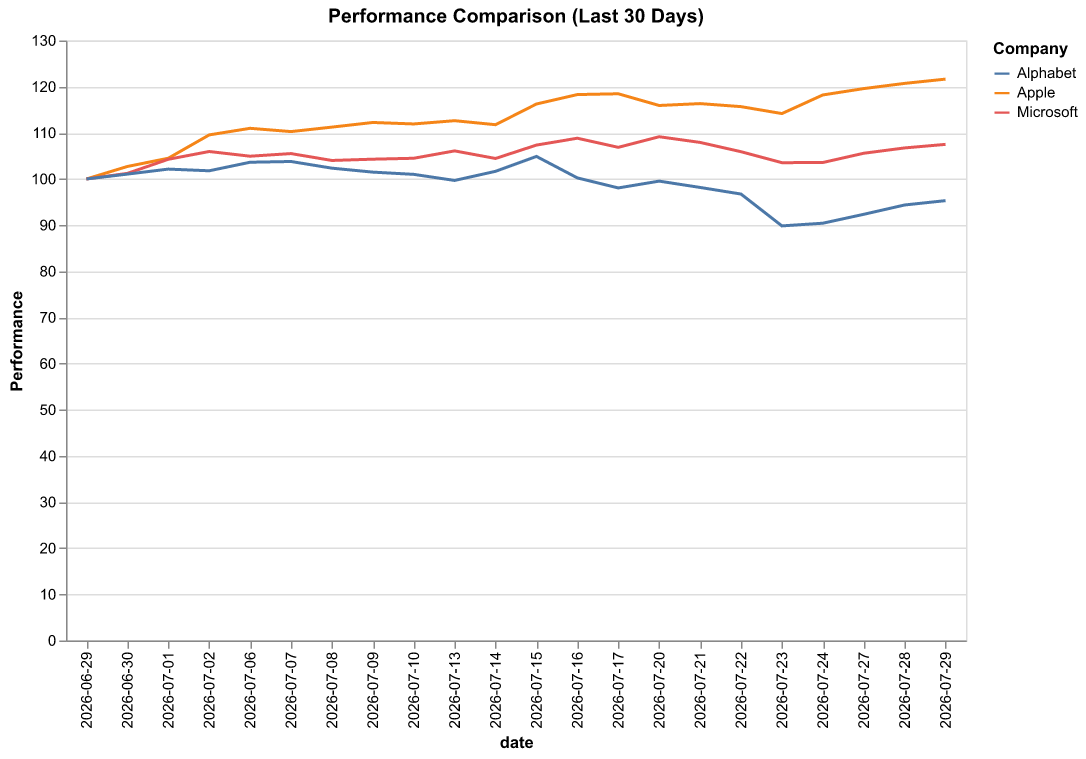

spec saved to output/chart_0cef03b291b9.vl.json, image saved to output/chart_0cef03b291b9.png (140 KB)


In [10]:
chart_result = client.research(
    message="Chart the S&P 500 (SPX) index level over the last 30 days, compare it with Apple, Google, and Microsoft.",
    research_effort="lite",
    chart_generation=True,
    on_event=make_progress_printer(),
)

print(f"\ncharts returned: {len(chart_result.charts)}")
for chart in chart_result.charts:
    render_chart(chart)

---
## 6. Other output formats

| Method | Returns |
|--------|---------|
| `get_answer()` | Plain answer text |
| `get_answer_with_citations()` | Answer with `[1]`, `[2, 3]` markers |
| `get_markdown_with_citations()` | Answer plus a Sources section |
| `get_numbered_citations()` | Citations numbered to match the inline markers |
| `get_citations()` / `get_citations_json()` | Every document returned by search |
| `to_dict()` / `to_json()` | Full result |
| `to_dict_with_inline_citations()` / `to_json_with_inline_citations()` | Full result, answer annotated |

Pass `include_tool_citations=False` to any of the citation methods for a document-only reference list.

In [11]:
# Plain answer, no markers
print(result.get_answer()[:400], "...\n")

# Document citations only, in Bigdata.com citation format
citations = result.get_citations()
print(f"{len(citations)} documents collected from search\n")
print(json.dumps(citations[0], indent=2)[:900], "...")

### Executive Summary
The Nasdaq 100 is currently undergoing a period of correction, having pulled back roughly 8% from recent peaks amid growing investor skepticism regarding the long-term sustainability of the artificial intelligence infrastructure spending boom . While the index maintains a positive year-to-date return, its recent 30-day performance reflects a challenging environment characteri ...

20 documents collected from search

{
  "id": "76f8718f7052909ee3aeb6d8ac051263",
  "headline": "Nasdaq 100 YTD Return",
  "source": {
    "name": "Slickcharts"
  },
  "url": "https://www.slickcharts.com/nasdaq100/returns/ytd",
  "source_type": "EXTERNAL",
  "chunks": [
    {
      "text": "Nasdaq 100 Year to Date Return for 2026. 9.95%. As of the market close on 2026-07-28. Historical Returns \u00b7 Component Returns. Data Details."
    }
  ]
} ...


---
## 7. Save results

In [12]:
outputs = {
    "output/citations.json": result.get_citations_json(),
    "output/research_result.json": result.to_json(),
    "output/result_with_inline_citations.json": result.to_json_with_inline_citations(),
}

for path, content in outputs.items():
    with open(path, "w") as fh:
        fh.write(content)
    print(f"saved {path} ({len(content):,} bytes)")

saved output/citations.json (31,848 bytes)
saved output/research_result.json (35,904 bytes)
saved output/result_with_inline_citations.json (12,878 bytes)


---
## 8. Follow-up questions

`follow_up()` reuses the previous result's `chat_id`, so the agent keeps the earlier turns in context. This requires `persistence_mode="enabled"` on the client; with the API default of `"disabled"` no history is saved and the follow-up starts cold.

In [13]:
follow_up_result = client.follow_up(
    "Which sectors are driving that performance?",
    previous_result=result,
    research_effort="lite",
)

print(f"same conversation: {follow_up_result.chat_id == result.chat_id}\n")
display(Markdown(follow_up_result.get_answer_with_citations()))

same conversation: True



The performance of the Nasdaq 100 is disproportionately driven by the **Technology** sector, which accounts for over half of the index's total value [1]. Within this sector, the narrative is currently bifurcated between high-growth hardware segments and cooling software/services.

### Key Sector Drivers
*   **Semiconductors and Storage:** This remains the primary engine for the index. Recent performance has been heavily concentrated in semiconductor equipment, storage solutions, and chip manufacturers. The market has been aggressive in pricing in demand for AI computing power, driving significant interest in companies that provide the essential infrastructure (e.g., storage, advanced packaging, and CPU/GPU hardware) [2]. 
*   **AI Infrastructure Hardware:** As the industry transitions from "training" to "deployment" of AI agents, demand for data movement and inference coordination has favored companies that sell full-stack AI infrastructure (including liquid-cooled racks and specialized networking). This segment continues to be a dominant force in index weightings.

### Areas of Pressure
*   **SaaS and Internet Services:** While hardware has driven much of the growth, other sub-sectors within the broader Nasdaq umbrella, such as SaaS (Software as a Service), internet services, and e-commerce, have acted as significant drags on recent index performance. These segments are facing increased scrutiny regarding margin sustainability and their ability to justify high valuations in a cautious economic environment.
*   **Cybersecurity:** High volatility in major cybersecurity components (e.g., CrowdStrike) has introduced idiosyncratic risk, significantly impacting daily index movements.

### Summary Table: Sector YTD Performance
*As of July 29, 2026*

| Sector | YTD Performance | Trend/Context |
|---|---|---|
| **Technology** | +17.25% | Driven by semiconductor/hardware demand. |
| **Communication Services** | -6.80% | Significant YTD lag compared to hardware segments. |
| **Consumer Discretionary** | -5.87% | Weakness in the last 30 days (-4.03%). |
| **Energy** | +31.38% | Strong peripheral performer, though less critical to total NDX returns than Tech. |

*Note: Data from State Street Sector SPDR ETFs as of July 29, 2026 [3].*

In [14]:
numbered_citations = follow_up_result.get_numbered_citations()

display(Markdown(f"---\n## References ({len(numbered_citations)})\n"))
print_citation(numbered_citations)

---
## References (3)


**[1]** Prediction: Tesla Stock Will Plunge to $100 If the Nasdaq Enters a Bear Market<br>The Globe And Mail &nbsp;|&nbsp; Jul 27, 2026<br>[https://www.theglobeandmail.com/investing/markets/markets-news/Motley%](https://www.theglobeandmail.com/investing/markets/markets-news/Motley%20Fool/3485745/prediction-tesla-stock-will-plunge-to-100-if-the-nasdaq-enters-a-bear-market/)

> *Key Points The Nasdaq-100 technology index is down 8% from its recent peak, due to concerns about the sustainability of the artificial intelligence infrastructure spending boom. Last time the Nasdaq-100 plunged by 20% and entered a bear market, Tesla stock plummeted by 75% to around $100. History co...*

---

**[2]** Overseas Computing Power Industry - Strong Performance Realization from Upstream Optical, Rising Demand from Downstream Capital Expenditure Boosts Prosperity<br>China Galaxy Securities Co., Ltd. &nbsp;|&nbsp; May 12, 2026<br>[https://research.bluematrix.com/docs/pdf/6d7924a6-8744-46cb-89b8-222c8](https://research.bluematrix.com/docs/pdf/6d7924a6-8744-46cb-89b8-222c82a25075/f0caba08-86e0-468d-b327-ca2a16a88734)

> *Core Viewpoints Overseas Computing Power Industry Recommended, Maintain Rating Analyst Zhao Liangbi 010-8092-7619 : zhaoliangbi_yj@chinastock.com.cn Analyst Registration Code: S0130522030003 Major indices maintained their upward trend this week, with tech indices outperforming the market: For the we...*

---

**[3]** get_market_tearsheet<br>Bigdata.com tool &nbsp;`get_market_tearsheet`

---

---
## 9. Error handling

Failures arrive in two layers, and they need different treatment.

**HTTP level** - raised before the stream starts, mapped to typed exceptions:

| Status | Exception | Retryable |
|-------:|-----------|-----------|
| `400` / `422` | `InvalidRequestError` | No |
| `401` | `AuthenticationError` | No |
| `403` | `EntitlementError` | No |
| `404` | `ResourceNotFoundError` | No |
| `429` | `RateLimitError` | Yes, with backoff |
| `5xx` | `ServerError` | Yes, with backoff |

**Stream level** - typed messages inside a `200` response:

| Message | Handling |
|---------|----------|
| `LLM_RETRY` | Logged. The agent recovers on its own |
| `TOOL_ERROR` | Counted in `result.tool_errors`, never raised. Check it to detect a degraded answer |
| `ERROR` | Raised as `StreamError`. The stream is over |
| No `COMPLETE` | Raised as `TruncatedStreamError`, so a truncated stream never looks like an empty answer |

All of these derive from `ResearchAgentError`.

In [15]:
from research_client import ResearchAgentError

# A rejected credential surfaces as a typed exception before the stream starts,
# rather than as a silently empty answer. The API answers 401 or 403 depending
# on whether the key is malformed or simply unknown.
try:
    ResearchClient(api_key="not-a-real-key").research("test", research_effort="lite")
except ResearchAgentError as exc:
    print(f"{type(exc).__name__}: {exc}")

EntitlementError: Not entitled to this resource (403): {"status_code": 403, "message": "Authorization failed for this resource.", "request_id": "019faef4-362f-7323-8c24-71efc756b11e"}


In [16]:
# A degraded answer is visible without inspecting the stream.
if result.tool_errors:
    print("Some sources could not be retrieved; the answer may be incomplete.")
    for tool, count in result.tool_errors.items():
        print(f"  {tool}: {count} failure(s)")
else:
    print("No tool errors - every source was retrieved.")

No tool errors - every source was retrieved.


---
## Citation format reference

Document citations follow the standard Bigdata.com format. Only non-null fields are included.

```json
{
  "number": 2,
  "id": "80CBFA19A18071707AADAC6765E1F9F0",
  "headline": "SC SECTOR WATCH",
  "timestamp": "2026-07-27T10:32:26",
  "source": {"id": "7ED2AF", "name": "S&P Capital IQ NetAdvantage", "rank": "RANK_2"},
  "url": "https://...",
  "source_type": "BIGDATA",
  "chunks": [
    {"cnum": 5, "text": "Relevant excerpt...", "relevance": 0.94, "sentiment": 0.82}
  ]
}
```

Whole-tool attributions use a distinct shape, flagged by `"type": "TOOL"`:

```json
{
  "number": 1,
  "type": "TOOL",
  "tool_name": "get_market_tearsheet",
  "audit_id": "action_70282a87",
  "title": "Market Tearsheet"
}
```

### Source shapes

`source` on a grounding reference is one of two shapes, discriminated on `type`:

| | `BIGDATA` | `EXTERNAL` |
|---|---|---|
| Publisher name | `src_name` | `action.name` |
| URL | `url` | `action.url` |
| Headline | `hd` | `hd` |
| Date | `ts` | `ts` |

Reading only the `BIGDATA` field names is why external web results used to appear without a publisher or link. The client normalises both shapes onto the same `Citation` fields.

### Deduplication

Sources are deduplicated by `id`, falling back to `url`, then `hd`. Headlines are the last resort because unrelated documents can share a title - deduplicating on them merges distinct articles into one reference.